In [1]:
from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

data_dir = './data'
batch_size = 64

fashion_mnist_dataset = FashionMNIST(data_dir, download=True, train=True, transform=transform)
train_dataloader = DataLoader(fashion_mnist_dataset, batch_size=batch_size, shuffle=True)

class_names = fashion_mnist_dataset.classes


In [2]:
data_dir = './data'
batch_size = 64

fashion_mnist_dataset = FashionMNIST(data_dir, download=True, train=True, transform=transform)
train_dataloader = DataLoader(fashion_mnist_dataset, batch_size=batch_size, shuffle=True)

class_names = fashion_mnist_dataset.classes

In [3]:
sample_size = 5000
indices = torch.randperm(len(fashion_mnist_dataset))[:sample_size]
subset = Subset(fashion_mnist_dataset, indices)
subset_loader = DataLoader(subset, batch_size=sample_size, shuffle=False)

images, labels = next(iter(subset_loader))

images_flat = images.view(sample_size, -1)

X = images_flat.numpy()
y = labels.numpy()

In [4]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X)

C:\Users\chock\miniconda3\envs\cs5340\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


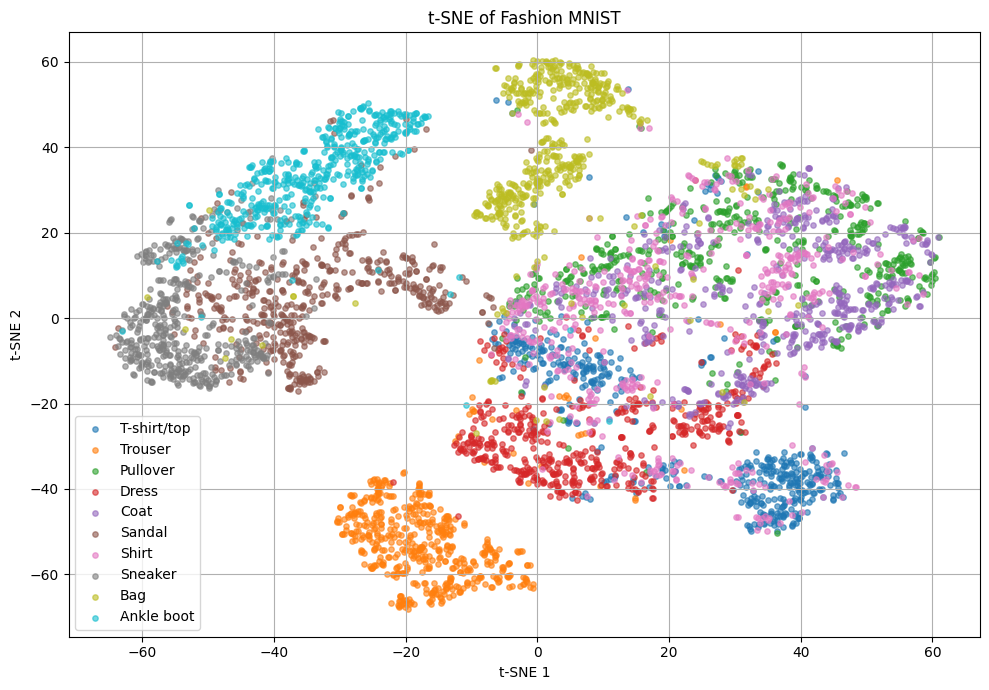

In [6]:
palette = np.array(sns.color_palette("tab10", 10))

plt.figure(figsize=(10, 7))
for i in range(10):
    idx = y == i
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], 
                label=class_names[i], s=15, alpha=0.6)

plt.legend()
plt.title("t-SNE of Fashion MNIST")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.show()